In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

READ DATA

In [2]:

# ==========================================
# 1. خواندن داده
# ==========================================

data = pd.read_csv("E:/pro/uni_project/adjusted_dataset_mlALL.csv")
df = data.copy()

df = df.dropna()

FEATURE ENGINEERING

In [3]:
# ==========================================
# FINAL FEATURE ENGINEERING
# ==========================================

import numpy as np
import pandas as pd

# ------------------------------------------
# 1. آماده‌سازی داده
# ------------------------------------------

df = df.copy().sort_index()

df["CLOSE"] = df["adj_close"]
df["HIGH_LOW"] = df["adj_high"] - df["adj_low"]
df["OPEN_CLOSE"] = df["adj_close"] - df["adj_open"]

df["OPEN_CLOSE_PCT"] = (
    (df["adj_close"] - df["adj_open"]) / df["adj_open"]
) * 100

df["CLOSE_CHANGE_PCT"] = df["adj_close"].pct_change() * 100
df["VOLUME"] = df["VOL"]

df["MA_5"] = df["CLOSE"].rolling(5).mean()
df["MA_10"] = df["CLOSE"].rolling(10).mean()
df["VOL_MA_5"] = df["VOLUME"].rolling(5).mean()


# ------------------------------------------
# 2. Lag Features
# ------------------------------------------

for lag in range(1, 21):
    df[f"CLOSE_LAG_{lag}"] = df["CLOSE"].shift(lag)


# ------------------------------------------
# 3. Returns
# ------------------------------------------

for period in [1, 3, 5, 10, 20]:
    df[f"RETURN_{period}"] = df["CLOSE"].pct_change(period)


# ------------------------------------------
# 4. Moving Averages
# ------------------------------------------

df["MA_20"] = df["CLOSE"].rolling(20).mean()
df["MA_60"] = df["CLOSE"].rolling(60).mean()

for ma in [5, 10, 20, 60]:
    df[f"CLOSE_MA{ma}_DIFF_PCT"] = (
        (df["CLOSE"] - df[f"MA_{ma}"]) / df[f"MA_{ma}"]
    ) * 100


# ------------------------------------------
# 5. Volatility
# ------------------------------------------

for period in [5, 10, 20, 60]:
    df[f"STD_{period}"] = df["CLOSE"].rolling(period).std()


# ------------------------------------------
# 6. EWMA
# ------------------------------------------

df["EWMA_12"] = df["CLOSE"].ewm(
    span=12, adjust=False
).mean()

df["EWMA_26"] = df["CLOSE"].ewm(
    span=26, adjust=False
).mean()


# ------------------------------------------
# 7. RSI
# ------------------------------------------

delta = df["CLOSE"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))
df["RSI_CHANGE"] = df["RSI_14"].diff()


# ------------------------------------------
# 8. MACD
# ------------------------------------------

ema_12 = df["CLOSE"].ewm(
    span=12, adjust=False
).mean()

ema_26 = df["CLOSE"].ewm(
    span=26, adjust=False
).mean()

df["MACD"] = ema_12 - ema_26

df["MACD_SIGNAL"] = df["MACD"].ewm(
    span=9, adjust=False
).mean()

df["MACD_HIST"] = (
    df["MACD"] - df["MACD_SIGNAL"]
)


# ------------------------------------------
# 9. Momentum
# ------------------------------------------

df["ROC_5"] = df["CLOSE"].pct_change(5)
df["ROC_10"] = df["CLOSE"].pct_change(10)


# ------------------------------------------
# 10. Bollinger Band Width
# ------------------------------------------

rolling_mean_20 = df["CLOSE"].rolling(20).mean()
rolling_std_20 = df["CLOSE"].rolling(20).std()

upper_band = rolling_mean_20 + 2 * rolling_std_20
lower_band = rolling_mean_20 - 2 * rolling_std_20

df["BB_WIDTH"] = (
    (upper_band - lower_band) / rolling_mean_20
)


# ------------------------------------------
# 11. Realized Volatility
# ------------------------------------------

returns = df["CLOSE"].pct_change()

df["REALIZED_VOLATILITY"] = (
    returns.rolling(20).std() * np.sqrt(20)
)


# ------------------------------------------
# 12. Volume Features
# ------------------------------------------

df["VOL_MA_20"] = df["VOLUME"].rolling(20).mean()

df["VOLUME_RATIO"] = (
    df["VOLUME"] / df["VOL_MA_20"]
)

df["VOLUME_CHANGE"] = df["VOLUME"].pct_change()

df["VOL_MA_RATIO_5_20"] = (
    df["VOL_MA_5"] / df["VOL_MA_20"]
)


# ------------------------------------------
# 13. Target
# ------------------------------------------

df["TARGET"] = df["CLOSE"].shift(-1)


# ==========================================
# 14. Final Features
# ==========================================

features_engineered = [
    # Price / Daily Movement
    "HIGH_LOW",
    "OPEN_CLOSE",
    "OPEN_CLOSE_PCT",
    "CLOSE_CHANGE_PCT",

    # Volume
    "VOLUME",
    "VOL_MA_5",

    # Lag
    *[f"CLOSE_LAG_{i}" for i in range(1, 21)],

    # Returns
    "RETURN_1",
    "RETURN_3",
    "RETURN_5",
    "RETURN_10",
    "RETURN_20",

    # Moving Average Distance
    "CLOSE_MA5_DIFF_PCT",
    "CLOSE_MA10_DIFF_PCT",
    "CLOSE_MA20_DIFF_PCT",
    "CLOSE_MA60_DIFF_PCT",

    # Volatility
    "STD_5",
    "STD_10",
    "STD_20",
    "STD_60",

    # EWMA
    "EWMA_12",
    "EWMA_26",

    # RSI
    "RSI_14",
    "RSI_CHANGE",

    # MACD
    "MACD",
    "MACD_SIGNAL",
    "MACD_HIST",

    # Momentum
    "ROC_5",
    "ROC_10",
    "BB_WIDTH",
    "REALIZED_VOLATILITY",

    # Volume Indicators
    "VOL_MA_20",
    "VOLUME_RATIO",
    "VOLUME_CHANGE",
    "VOL_MA_RATIO_5_20"
]


# ==========================================
# 15. ساخت دیتاست نهایی
# ==========================================

model_df = df[
    features_engineered + ["TARGET"]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna().copy()


# ==========================================
# 16. Train / Test Split
# ==========================================

split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[features_engineered]
y_train = train_df["TARGET"]

X_test = test_df[features_engineered]
y_test = test_df["TARGET"]


# ==========================================
# نمایش اطلاعات
# ==========================================

print("=" * 50)
print("FINAL DATASET")
print("=" * 50)

print("Number of rows:", len(model_df))
print("Number of features:", len(features_engineered))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nFeatures:")
for i, feature in enumerate(features_engineered, 1):
    print(f"{i:2d}. {feature}")

print("\nTARGET = CLOSE of next day")

FINAL DATASET
Number of rows: 4137
Number of features: 54
X_train: (3309, 54)
X_test : (828, 54)

Features:
 1. HIGH_LOW
 2. OPEN_CLOSE
 3. OPEN_CLOSE_PCT
 4. CLOSE_CHANGE_PCT
 5. VOLUME
 6. VOL_MA_5
 7. CLOSE_LAG_1
 8. CLOSE_LAG_2
 9. CLOSE_LAG_3
10. CLOSE_LAG_4
11. CLOSE_LAG_5
12. CLOSE_LAG_6
13. CLOSE_LAG_7
14. CLOSE_LAG_8
15. CLOSE_LAG_9
16. CLOSE_LAG_10
17. CLOSE_LAG_11
18. CLOSE_LAG_12
19. CLOSE_LAG_13
20. CLOSE_LAG_14
21. CLOSE_LAG_15
22. CLOSE_LAG_16
23. CLOSE_LAG_17
24. CLOSE_LAG_18
25. CLOSE_LAG_19
26. CLOSE_LAG_20
27. RETURN_1
28. RETURN_3
29. RETURN_5
30. RETURN_10
31. RETURN_20
32. CLOSE_MA5_DIFF_PCT
33. CLOSE_MA10_DIFF_PCT
34. CLOSE_MA20_DIFF_PCT
35. CLOSE_MA60_DIFF_PCT
36. STD_5
37. STD_10
38. STD_20
39. STD_60
40. EWMA_12
41. EWMA_26
42. RSI_14
43. RSI_CHANGE
44. MACD
45. MACD_SIGNAL
46. MACD_HIST
47. ROC_5
48. ROC_10
49. BB_WIDTH
50. REALIZED_VOLATILITY
51. VOL_MA_20
52. VOLUME_RATIO
53. VOLUME_CHANGE
54. VOL_MA_RATIO_5_20

TARGET = CLOSE of next day


CALCULATE ACCURACY

In [33]:
def directional_accuracy(actual, predicted, previous):
    
    actual_change = actual - previous
    predicted_change = predicted - previous
    
    valid = actual_change != 0
    
    actual_direction = np.sign(
        actual_change[valid]
    )
    
    predicted_direction = np.sign(
        predicted_change[valid]
    )
    
    return (
        actual_direction == predicted_direction
    ).mean() * 100

NAIVE BASELINE

In [31]:
# ============================================================
# NAIVE BASELINE
# پیش‌بینی قیمت فردا = قیمت امروز
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 60)
print("NAIVE BASELINE")
print("=" * 60)

# ------------------------------------------------------------
# 1. آماده‌سازی داده
# ------------------------------------------------------------

naive_df = df.copy().sort_index()

# قیمت تعدیل‌شده
naive_df["CLOSE"] = naive_df["adj_close"]

# قیمت روز بعد
naive_df["NEXT_CLOSE"] = naive_df["CLOSE"].shift(-1)

# حذف ردیف آخر و مقادیر نامعتبر
naive_df = naive_df[
    ["CLOSE", "NEXT_CLOSE"]
].replace([np.inf, -np.inf], np.nan).dropna()

print("Number of rows:", len(naive_df))

# ------------------------------------------------------------
# 2. همان تقسیم 80/20
# ------------------------------------------------------------

split = int(len(naive_df) * 0.8)

train = naive_df.iloc[:split]
test = naive_df.iloc[split:]

# ------------------------------------------------------------
# 3. Naive Prediction
# پیش‌بینی قیمت فردا = قیمت امروز
# ------------------------------------------------------------

y_test = test["NEXT_CLOSE"].values

y_pred = test["CLOSE"].values

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

smape = np.mean(
    2 * np.abs(y_pred - y_test) /
    (np.abs(y_test) + np.abs(y_pred) + 1e-8)
) * 100

# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NAIVE RESULTS")
print("=" * 60)

print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"SMAPE : {smape:.4f}%")

# ------------------------------------------------------------
# 6. Directional Accuracy
# ------------------------------------------------------------

# قیمت روز قبل از هر روز Test
previous_close = np.concatenate([
    [train["CLOSE"].iloc[-1]],
    test["CLOSE"].values[:-1]
])

# Naive: جهت پیش‌بینی‌شده = جهت حرکت قیمت امروز نسبت به روز قبل
predicted_price_for_direction = (
    test["CLOSE"].values
    + (test["CLOSE"].values - previous_close)
)

naive_directional_accuracy = directional_accuracy(
    y_test,
    predicted_price_for_direction,
    test["CLOSE"].values
)

print(f"Directional Accuracy : {naive_directional_accuracy:.2f}%")

NAIVE BASELINE
Number of rows: 4196

NAIVE RESULTS
MAE   : 33.7666
RMSE  : 55.8011
SMAPE : 1.6137%
Directional Accuracy : 60.15%


AR MODEL

AR(1) - WALK-FORWARD
Total samples : 4197
Train samples : 3357
Test samples  : 840


AR(1) - WALK-FORWARD RESULTS
MAE                  : 34.1143
RMSE                 : 55.8724
MAPE                 : 1.6274%
SMAPE                : 1.6293%
Directional Accuracy: 45.74%


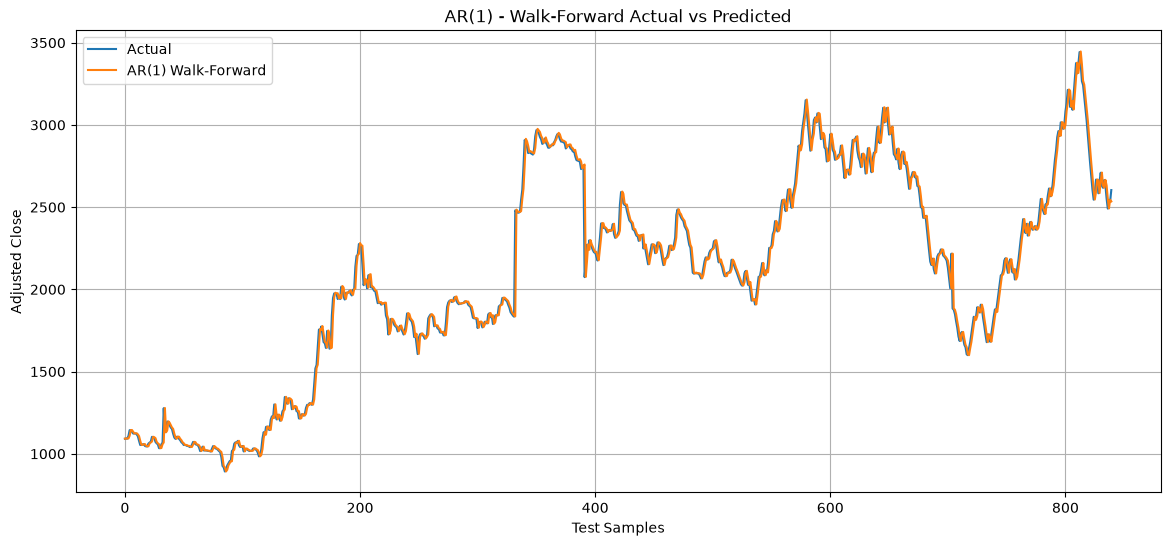

In [19]:
# ============================================================
# AR(1) - Walk-Forward One-Step-Ahead Forecasting
# + MAE / RMSE / MAPE / SMAPE
# + Directional Accuracy
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 1. آماده‌سازی داده
# ============================================================

data = df.copy()

data = data.sort_index()

# استفاده از قیمت تعدیل‌شده
data["CLOSE"] = data["adj_close"]

data = data[["CLOSE"]].dropna()

prices = data["CLOSE"].values


# ============================================================
# 2. تقسیم Train / Test
# ============================================================

TEST_SIZE = 0.20

split_index = int(
    len(prices) * (1 - TEST_SIZE)
)

train = prices[:split_index].copy()
test = prices[split_index:].copy()


print("=" * 65)
print("AR(1) - WALK-FORWARD")
print("=" * 65)

print(f"Total samples : {len(prices)}")
print(f"Train samples : {len(train)}")
print(f"Test samples  : {len(test)}")


# ============================================================
# 3. Walk-Forward Forecasting
# ============================================================

history = list(train)

ar_predictions = []

previous_prices = []


for i in range(len(test)):

    # --------------------------------------------------------
    # قیمت روز قبل
    # --------------------------------------------------------

    previous_price = history[-1]

    previous_prices.append(previous_price)


    # --------------------------------------------------------
    # آموزش AR(1) روی تمام اطلاعات موجود تا این لحظه
    # --------------------------------------------------------

    ar_model = AutoReg(
        history,
        lags=1,
        trend="c",
        old_names=False
    )

    ar_fit = ar_model.fit()


    # --------------------------------------------------------
    # پیش‌بینی فقط روز بعد
    # --------------------------------------------------------

    prediction = ar_fit.predict(
        start=len(history),
        end=len(history)
    )

    prediction = float(prediction.iloc[0] if hasattr(
        prediction, "iloc"
    ) else prediction[0])

    ar_predictions.append(prediction)


    # --------------------------------------------------------
    # بعد از مشخص شدن مقدار واقعی،
    # آن را به History اضافه می‌کنیم
    # --------------------------------------------------------

    history.append(test[i])


ar_predictions = np.array(ar_predictions)

previous_prices = np.array(previous_prices)


# ============================================================
# 4. محاسبه MAE
# ============================================================

ar_mae = mean_absolute_error(
    test,
    ar_predictions
)


# ============================================================
# 5. محاسبه RMSE
# ============================================================

ar_rmse = np.sqrt(
    mean_squared_error(
        test,
        ar_predictions
    )
)


# ============================================================
# 6. محاسبه MAPE
# ============================================================

ar_mape = np.mean(
    np.abs(
        (test - ar_predictions) /
        (test + 1e-10)
    )
) * 100


# ============================================================
# 7. محاسبه SMAPE
# ============================================================

ar_smape = np.mean(
    2 * np.abs(
        ar_predictions - test
    ) /
    (
        np.abs(test) +
        np.abs(ar_predictions) +
        1e-10
    )
) * 100


# ============================================================
# 8. Directional Accuracy
# ============================================================

ar_directional_accuracy = directional_accuracy(
    test,
    ar_predictions,
    previous_prices
)

# ============================================================
# 9. نمایش نتایج
# ============================================================

print("\n")
print("=" * 65)
print("AR(1) - WALK-FORWARD RESULTS")
print("=" * 65)

print(f"MAE                  : {ar_mae:.4f}")
print(f"RMSE                 : {ar_rmse:.4f}")
print(f"MAPE                 : {ar_mape:.4f}%")
print(f"SMAPE                : {ar_smape:.4f}%")
print(
    f"Directional Accuracy: {ar_directional_accuracy:.2f}%"
)


# ============================================================
# 10. نمودار Actual vs Predicted
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    ar_predictions,
    label="AR(1) Walk-Forward"
)

plt.title(
    "AR(1) - Walk-Forward Actual vs Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Adjusted Close")

plt.legend()
plt.grid(True)

plt.show()

ARMA MODEL

c:\Users\cebit\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ARMA(1,1) - WALK-FORWARD WITH MODEL UPDATE
MAE                  : 33.1787
RMSE                 : 57.4920
MAPE                 : 1.5964%
SMAPE                : 1.5989%
Directional Accuracy : 65.04%


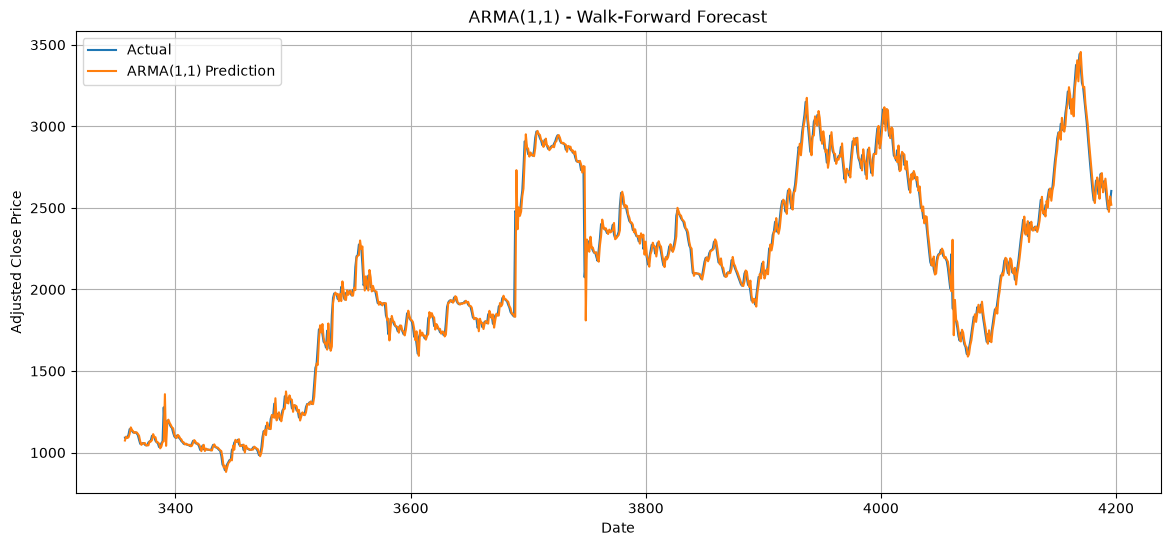

In [15]:
# ============================================================
# ARMA(1,1) - Walk-Forward با به‌روزرسانی مدل
# بدون برازش مجدد در هر روز
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ------------------------------------------------------------
# 1. آماده‌سازی داده
# ------------------------------------------------------------

data = df.copy()

data = data.sort_index()

data["CLOSE"] = data["adj_close"]

series = data["CLOSE"].dropna()

# تقسیم 80/20 به صورت زمانی
split = int(len(series) * 0.80)

train = series.iloc[:split]
test = series.iloc[split:]


# ------------------------------------------------------------
# 2. برازش اولیه ARMA(1,1) فقط یک بار
# ------------------------------------------------------------

arma_model = ARIMA(
    train,
    order=(1, 0, 1)
)

arma_fit = arma_model.fit()


# ------------------------------------------------------------
# 3. Walk-Forward Forecast
# ------------------------------------------------------------

history_result = arma_fit

arma_predictions = []
previous_prices = []

for actual_value in test:

    # قیمت روز قبل
    previous_price = (
        train.iloc[-1]
        if len(previous_prices) == 0
        else test.iloc[len(previous_prices) - 1]
    )

    previous_prices.append(previous_price)

    # پیش‌بینی فقط روز بعد
    forecast = history_result.forecast(steps=1)

    prediction = float(forecast.iloc[0])

    arma_predictions.append(prediction)

    # --------------------------------------------------------
    # به‌روزرسانی مدل با مقدار واقعی مشاهده‌شده
    # بدون برازش مجدد پارامترها
    # --------------------------------------------------------

    history_result = history_result.append(
        [actual_value],
        refit=False
    )


# تبدیل به آرایه
arma_predictions = np.array(arma_predictions)
previous_prices = np.array(previous_prices)
actual_values = test.values


# ------------------------------------------------------------
# 4. معیارهای ارزیابی
# ------------------------------------------------------------

mae = mean_absolute_error(
    actual_values,
    arma_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        arma_predictions
    )
)

mape = np.mean(
    np.abs(
        (actual_values - arma_predictions)
        / actual_values
    )
) * 100

smape = np.mean(
    2 * np.abs(actual_values - arma_predictions)
    / (
        np.abs(actual_values)
        + np.abs(arma_predictions)
    )
) * 100


# ------------------------------------------------------------
# 5. Directional Accuracy
# ------------------------------------------------------------

directional_accuracy = directional_accuracy(
    actual_values,
    arma_predictions,
    previous_prices
)


# ------------------------------------------------------------
# 6. نمایش نتایج
# ------------------------------------------------------------

print("=" * 60)
print("ARMA(1,1) - WALK-FORWARD WITH MODEL UPDATE")
print("=" * 60)

print(f"MAE                  : {mae:.4f}")
print(f"RMSE                 : {rmse:.4f}")
print(f"MAPE                 : {mape:.4f}%")
print(f"SMAPE                : {smape:.4f}%")
print(f"Directional Accuracy : {directional_accuracy:.2f}%")

print("=" * 60)


# ------------------------------------------------------------
# 7. نمودار Actual vs Predicted
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    actual_values,
    label="Actual"
)

plt.plot(
    test.index,
    arma_predictions,
    label="ARMA(1,1) Prediction"
)

plt.title("ARMA(1,1) - Walk-Forward Forecast")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)

plt.show()

ARIMA MODEL

In [23]:
# ==========================================
# ARIMA(0,1,1) - One Step Ahead
# ==========================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ------------------------------------------
# 1. سری قیمت
# ------------------------------------------

price = df["CLOSE"].copy()


# ------------------------------------------
# 2. تقسیم Train / Test
# ------------------------------------------

split_index = int(len(price) * 0.8)

train = price.iloc[:split_index]
test = price.iloc[split_index:]

print("Train:", len(train))
print("Test :", len(test))


# ------------------------------------------
# 3. One-Step Ahead Forecast
# ------------------------------------------

history = list(train)
predictions = []

for i in range(len(test)):

    model = ARIMA(
        history,
        order=(0, 1, 1)
    )

    model_fit = model.fit()

    prediction = model_fit.forecast(steps=1)[0]

    predictions.append(prediction)

    # اضافه کردن قیمت واقعی همان روز به تاریخچه
    history.append(test.iloc[i])


# ------------------------------------------
# 4. Metrics
# ------------------------------------------

y_true = test.values
y_pred = np.array(predictions)

# MAE
mae = mean_absolute_error(
    y_true,
    y_pred
)

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

# SMAPE
smape = np.mean(
    2 * np.abs(y_pred - y_true)
    /
    (
        np.abs(y_true) + np.abs(y_pred) + 1e-8
    )
) * 100


# ------------------------------------------
# 5. Directional Accuracy
# ------------------------------------------

# قیمت روز قبل برای هر روز Test
previous_prices = np.concatenate([
    [train.iloc[-1]],
    test.values[:-1]
])

# استفاده از تابع مشترک
arima_directional_accuracy = directional_accuracy(
    y_true,
    y_pred,
    previous_prices
)


# ==========================================
# 6. نمایش نتایج
# ==========================================

print("\n" + "=" * 50)
print("ARIMA(0,1,1) - One Step Ahead")
print("=" * 50)

print(f"MAE                  : {mae:.4f}")
print(f"RMSE                 : {rmse:.4f}")
print(f"SMAPE                : {smape:.4f} %")
print(f"Directional Accuracy : {arima_directional_accuracy:.2f} %")

Train: 3357
Test : 840

ARIMA(0,1,1) - One Step Ahead
MAE                  : 33.4542
RMSE                 : 56.0659
SMAPE                : 1.6045 %
Directional Accuracy : 62.91 %


RIDGE REGRESSION MODEL

In [26]:
# ============================================================
# RIDGE REGRESSION
# FEATURE SET 2
# TARGET = NEXT-DAY PRICE CHANGE
# TIME-SERIES CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 1. Feature Set 2
# ============================================================

features_ridge = [

    # --------------------------------------
    # Price / Daily Movement
    # --------------------------------------
    "HIGH_LOW",
    "OPEN_CLOSE",
    "OPEN_CLOSE_PCT",
    "CLOSE_CHANGE_PCT",

    # --------------------------------------
    # Volume
    # --------------------------------------
    "VOLUME",
    "MA_5",
    "MA_10",
    "VOL_MA_5",

    # --------------------------------------
    # Lag
    # --------------------------------------
    *[f"CLOSE_LAG_{i}" for i in range(1, 21)],

    # --------------------------------------
    # Rolling
    # --------------------------------------
    "MA_20",
    "MA_60",

    "STD_5",
    "STD_10",
    "STD_20",
    "STD_60",

    # --------------------------------------
    # EWMA
    # --------------------------------------
    "EWMA_12",
    "EWMA_26",

    # --------------------------------------
    # Indicators
    # --------------------------------------
    "RSI_14",
    "MACD",
    "MACD_SIGNAL",

    "ROC_5",
    "ROC_10",

    "BB_WIDTH",
    "REALIZED_VOLATILITY",

    # --------------------------------------
    # Volume
    # --------------------------------------
    "VOL_MA_20",
    "VOLUME_RATIO"
]


# ============================================================
# 2. ساخت Target = تغییر قیمت روز بعد
# ============================================================

ridge_df = df.copy().sort_index()


ridge_df["CLOSE"] = ridge_df["adj_close"]


# قیمت روز بعد
ridge_df["NEXT_CLOSE"] = (
    ridge_df["CLOSE"].shift(-1)
)


# تغییر قیمت روز بعد
ridge_df["TARGET_CHANGE"] = (
    ridge_df["NEXT_CLOSE"]
    - ridge_df["CLOSE"]
)


# ============================================================
# 3. ساخت دیتاست نهایی Ridge
# ============================================================

ridge_model_df = ridge_df[
    features_ridge
    + [
        "CLOSE",
        "NEXT_CLOSE",
        "TARGET_CHANGE"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna().copy()


print("=" * 60)
print("RIDGE DATASET")
print("=" * 60)

print(
    "Number of rows:",
    len(ridge_model_df)
)

print(
    "Number of features:",
    len(features_ridge)
)


# ============================================================
# 4. X و Target
# ============================================================

X = ridge_model_df[
    features_ridge
]

y_change = ridge_model_df[
    "TARGET_CHANGE"
]

current_close = ridge_model_df[
    "CLOSE"
]

next_close = ridge_model_df[
    "NEXT_CLOSE"
]


# ============================================================
# 5. تابع SMAPE
# ============================================================

def smape(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    mask = denominator != 0

    return (
        100
        * np.mean(
            2
            * np.abs(
                y_pred[mask]
                - y_true[mask]
            )
            / denominator[mask]
        )
    )


# ============================================================
# 6. Time-Series Cross Validation
# ============================================================

n_splits = 5

n = len(X)

test_size = n // (n_splits + 1)


# ============================================================
# 7. Alphaهای مختلف Ridge
# ============================================================

alpha_values = [
    0.001,
    0.01,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
    20,
    50,
    100
]


alpha_results = []


# ============================================================
# 8. پیدا کردن بهترین Alpha
# ============================================================

for alpha in alpha_values:

    fold_scores = []


    for fold in range(n_splits):

        val_end = (
            n
            - (
                n_splits
                - fold
                - 1
            )
            * test_size
        )

        val_start = (
            val_end
            - test_size
        )

        train_end = val_start


        # -------------------------------
        # Train
        # -------------------------------

        X_train = X.iloc[:train_end]

        y_train = y_change.iloc[:train_end]


        # -------------------------------
        # Validation
        # -------------------------------

        X_val = X.iloc[
            val_start:val_end
        ]

        y_val = y_change.iloc[
            val_start:val_end
        ]

        close_val = current_close.iloc[
            val_start:val_end
        ]


        # -------------------------------
        # Ridge Pipeline
        # -------------------------------

        model = Pipeline([

            (
                "scaler",
                StandardScaler()
            ),

            (
                "ridge",
                Ridge(
                    alpha=alpha
                )
            )
        ])


        # -------------------------------
        # Training
        # -------------------------------

        model.fit(
            X_train,
            y_train
        )


        # -------------------------------
        # Predict Change
        # -------------------------------

        pred_change = model.predict(
            X_val
        )


        # -------------------------------
        # Convert to Price
        # -------------------------------

        pred_price = (
            close_val.values
            + pred_change
        )


        real_price = (
            close_val.values
            + y_val.values
        )


        # -------------------------------
        # SMAPE
        # -------------------------------

        score = smape(
            real_price,
            pred_price
        )


        fold_scores.append(
            score
        )


    alpha_results.append({

        "alpha": alpha,

        "Mean_SM​​APE":
            np.mean(fold_scores),

        "Std_SMAPE":
            np.std(fold_scores)
    })


# ============================================================
# 9. نتایج Alpha
# ============================================================

alpha_results_df = pd.DataFrame(
    alpha_results
)


alpha_results_df = (
    alpha_results_df
    .sort_values("Mean_SM​​APE")
    .reset_index(drop=True)
)


print("\n")
print("=" * 60)
print("RIDGE ALPHA SEARCH")
print("=" * 60)

print(
    alpha_results_df.to_string(
        index=False
    )
)


# ============================================================
# 10. بهترین Alpha
# ============================================================

best_alpha = (
    alpha_results_df.iloc[0]["alpha"]
)


print("\n")
print(
    "BEST ALPHA:",
    best_alpha
)

print(
    "BEST CV SMAPE:",
    alpha_results_df.iloc[0]["Mean_SM​​APE"]
)


# ============================================================
# 11. ارزیابی نهایی روی Test
# ============================================================

# 80% اول برای Train
split = int(
    len(X) * 0.8
)


X_train = X.iloc[:split]

X_test = X.iloc[split:]


y_train = y_change.iloc[:split]

y_test = y_change.iloc[split:]


close_test = current_close.iloc[
    split:
]


# ============================================================
# 12. مدل نهایی Ridge
# ============================================================

final_ridge = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "ridge",
        Ridge(
            alpha=best_alpha
        )
    )
])


# ============================================================
# 13. آموزش
# ============================================================

final_ridge.fit(
    X_train,
    y_train
)


# ============================================================
# 14. Prediction
# ============================================================

pred_change = final_ridge.predict(
    X_test
)


# ============================================================
# 15. تبدیل Change به Price
# ============================================================

pred_price = (
    close_test.values
    + pred_change
)


real_price = (
    close_test.values
    + y_test.values
)


# ============================================================
# 16. Metrics
# ============================================================

mae = mean_absolute_error(
    real_price,
    pred_price
)


rmse = np.sqrt(
    mean_squared_error(
        real_price,
        pred_price
    )
)


smape_score = smape(
    real_price,
    pred_price
)


# ============================================================
# 17. Final Result
# ============================================================

print("\n")
print("=" * 60)
print("FINAL RIDGE - FEATURE SET 2")
print("=" * 60)

print(
    "Number of features:",
    len(features_ridge)
)

print(
    "Best Alpha:",
    best_alpha
)

print(
    f"MAE   : {mae:.4f}"
)

print(
    f"RMSE  : {rmse:.4f}"
)

print(
    f"SMAPE : {smape_score:.4f}%"
)

# ============================================================
# 18. DIRECTIONAL ACCURACY
# ============================================================

previous_prices = close_test.values

ridge_directional_accuracy = directional_accuracy(
    real_price,
    pred_price,
    previous_prices
)

print(
    f"Directional Accuracy : "
    f"{ridge_directional_accuracy:.2f}%"
)

RIDGE DATASET
Number of rows: 4137
Number of features: 45


RIDGE ALPHA SEARCH
  alpha  Mean_SM​​APE  Std_SMAPE
100.000      1.535877   0.333354
 50.000      1.541202   0.335015
 20.000      1.550060   0.336382
 10.000      1.557526   0.336798
  5.000      1.565373   0.336954
  2.000      1.575022   0.336446
  1.000      1.581489   0.335940
  0.500      1.587813   0.335221
  0.100      1.606159   0.338070
  0.010      1.621104   0.342856
  0.001      1.623577   0.342714


BEST ALPHA: 100.0
BEST CV SMAPE: 1.5358773517098174


FINAL RIDGE - FEATURE SET 2
Number of features: 45
Best Alpha: 100.0
MAE   : 33.2058
RMSE  : 54.9904
SMAPE : 1.5868%
Directional Accuracy : 61.39%


XGBOOST MODEL

In [34]:
# ============================================================
# FINAL XGBOOST - TARGET_RETURN
# ============================================================

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 1. پارامترهای پیدا شده توسط Optuna
# ============================================================

BEST_PARAMS = {
    "n_estimators": 351,
    "learning_rate": 0.005060472373991083,
    "max_depth": 2,
    "min_child_weight": 14,
    "subsample": 0.6675859321475345,
    "colsample_bytree": 0.5630252735719202,
    "gamma": 3.880239265440295,
    "reg_alpha": 6.2935752765229145,
    "reg_lambda": 4.184660104870888
}


# ============================================================
# 2. ساخت Target
# ============================================================

model_df = df.copy()

model_df["CURRENT_CLOSE"] = model_df["CLOSE"]
model_df["NEXT_CLOSE"] = model_df["CLOSE"].shift(-1)

# درصد تغییر قیمت روز بعد
model_df["TARGET_RETURN"] = (
    (model_df["NEXT_CLOSE"] - model_df["CURRENT_CLOSE"])
    / model_df["CURRENT_CLOSE"]
) * 100


# ============================================================
# 3. حذف NaN
# ============================================================

model_df = model_df.dropna(
    subset=features_engineered + [
        "CURRENT_CLOSE",
        "NEXT_CLOSE",
        "TARGET_RETURN"
    ]
).copy()


X = model_df[features_engineered]
y = model_df["TARGET_RETURN"]

current_close = model_df["CURRENT_CLOSE"]
next_close = model_df["NEXT_CLOSE"]


# ============================================================
# 4. تقسیم زمانی
# ============================================================

split = int(len(model_df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

close_test = current_close.iloc[split:]
actual_next_close = next_close.iloc[split:]


print("=" * 60)
print("FINAL MODEL")
print("=" * 60)

print("Total :", len(model_df))
print("Train :", len(X_train))
print("Test  :", len(X_test))


# ============================================================
# 5. آموزش مدل با پارامترهای Optuna
# ============================================================

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **BEST_PARAMS
)

model.fit(X_train, y_train)


# ============================================================
# 6. پیش‌بینی درصد تغییر
# ============================================================

pred_return = model.predict(X_test)


# ============================================================
# 7. تبدیل درصد تغییر به قیمت پیش‌بینی‌شده
# ============================================================

pred_price = close_test.values * (
    1 + pred_return / 100
)


# ============================================================
# 8. محاسبه SMAPE
# ============================================================

def smape(y_true, y_pred):

    denominator = (
        np.abs(y_true) + np.abs(y_pred)
    )

    mask = denominator != 0

    return np.mean(
        2 * np.abs(y_pred[mask] - y_true[mask])
        / denominator[mask]
    ) * 100


# ============================================================
# 9. معیارهای رگرسیون
# ============================================================

mae = mean_absolute_error(
    actual_next_close,
    pred_price
)

rmse = np.sqrt(
    mean_squared_error(
        actual_next_close,
        pred_price
    )
)

smape_score = smape(
    actual_next_close.values,
    pred_price
)


print("\n" + "=" * 60)
print("REGRESSION RESULTS")
print("=" * 60)

print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"SMAPE : {smape_score:.4f}%")


# ============================================================
# 10. Directional Accuracy
# ============================================================

previous_prices = close_test.values

xgb_directional_accuracy = directional_accuracy(
    actual_next_close.values,
    pred_price,
    previous_prices
)

print(
    f"Directional Accuracy : "
    f"{xgb_directional_accuracy:.2f}%"
)

# ============================================================
# 11. جدول نتایج Test
# ============================================================

results = pd.DataFrame({
    "CURRENT_CLOSE": close_test.values,
    "ACTUAL_NEXT_CLOSE": actual_next_close.values,

    "ACTUAL_RETURN_%": actual_return,
    "PREDICTED_RETURN_%": pred_return,

    "PREDICTED_CLOSE": pred_price

}, index=X_test.index)


print("\n" + "=" * 60)
print("LAST TEST PREDICTIONS")
print("=" * 60)

print(
    results.tail(20).round(4)
)


# ============================================================
# 12. پیش‌بینی برای آخرین روز موجود دیتاست
# ============================================================

latest_X = X.iloc[[-1]]

latest_close = model_df["CURRENT_CLOSE"].iloc[-1]

latest_pred_return = model.predict(
    latest_X
)[0]

latest_pred_price = latest_close * (
    1 + latest_pred_return / 100
)


print("\n" + "=" * 60)
print("LATEST PREDICTION")
print("=" * 60)

print(f"Current Close     : {latest_close:.2f}")
print(f"Predicted Return  : {latest_pred_return:.4f}%")
print(f"Predicted Close   : {latest_pred_price:.2f}")

FINAL MODEL
Total : 4137
Train : 3309
Test  : 828

REGRESSION RESULTS
MAE   : 32.6461
RMSE  : 54.8623
SMAPE : 1.5599%
Directional Accuracy : 63.54%

LAST TEST PREDICTIONS
      CURRENT_CLOSE  ACTUAL_NEXT_CLOSE  ACTUAL_RETURN_%  PREDICTED_RETURN_%  \
4176      2937.9845          2850.3876          -2.9815             -0.6224   
4177      2850.3876          2765.1163          -2.9916             -0.7152   
4178      2765.1163          2682.1705          -2.9997             -0.8383   
4179      2682.1705          2605.4264          -2.8613             -0.8136   
4180      2605.4264          2545.7364          -2.2910             -0.6256   
4181      2545.7364          2592.2481           1.8270             -0.8966   
4182      2592.2481          2667.4419           2.9007              0.2269   
4183      2667.4419          2664.3411          -0.1162              0.2658   
4184      2664.3411          2584.4961          -2.9968             -0.4303   
4185      2584.4961          2657.3643 